In [3]:
import importlib
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# import deeptime
import scipy
import pandas as pd
import os


import iMSM.extensions.npc.npc
importlib.reload(iMSM.extensions.npc.npc)
from iMSM.extensions.npc.npc import run
# --
import raveh_2025.show_transport_stats_v3
importlib.reload(raveh_2025.show_transport_stats_v3)
from raveh_2025.show_transport_stats_v3 import read_df, calc_filtered_transport_stats
# --
import iMSM.extensions.npc.npc_utils
importlib.reload(iMSM.extensions.npc.npc_utils)
from utils import radius_a_to_kda, amount_to_concentration

In [20]:
for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [0.04, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1]: # 
            print (f"~~~~~~~ subset {subset} ~~~~~~~")
    # for radius in [22]:
            
            checkpoint_path = f"data/ntr_variants/{sites}_{radius}_more/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 70000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants/{sites}_{10}_more/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            
            # bootstraps:
            # params['BOOTSTRAP_REPEATS'] = 100
            # params['N_CLUSTERS'] = [640]
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [80]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 
            
            run(checkpoint_path, params_override=params, start_stage=6, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
~~~~~~~ subset 0.04 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1971.1767489884157 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ subset 0.05 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1518.5430140416 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ subset 0.1 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1309.8011621621758 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ subset 0.2 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1204.967735812096 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ subset 0.25 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1237.651098144768 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ subset 0.3 ~~~~~~~


In [21]:


n_sites = [2, 4, 6]
radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]

def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md():
    results = []
    for sites in n_sites:
        for radius in radii:
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=None)
            
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'total_transports': total_full_transports,
                'n_trajs': n_trajs,
                'permeability': permeability,
                'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                'upper_permeability': upper_permeability if upper_permeability >=0 else 0
            })
    return results

def collect_perms_md_single_type(kap_coords_folder, n_sims, start_time, end_time, shorten_time_to_us, step_ns=100):
    """
    Count transport events from raw 3D kap coordinates.
    
    kap_coords_folder: path containing subfolders 1, 2, ..., n_sims,
                       each with a file 'start_time-end_time.pickle' of shape (kap_amount, 3, n_frames).
    step_ns: time per frame in nanoseconds (default 100 ns).
    """
    # Load and concatenate raw 3D coordinates across all simulations
    all_coords = []
    for sim_idx in range(1, n_sims + 1):
        path = os.path.join(kap_coords_folder, str(sim_idx), f"{start_time}-{end_time}.pickle")
        with open(path, "rb") as f:
            coords = pickle.load(f)  # shape: (kap_amount, 3, n_frames)
        all_coords.append(coords)

    all_coords = np.concatenate(all_coords, axis=0)  # shape: (kap_amount * n_sims, 3, n_frames)

    _, _, n_frames = all_coords.shape
    time_us = n_frames * step_ns / 1000  # convert ns → µs

    if shorten_time_to_us is not None:
        if shorten_time_to_us > time_us:
            raise ValueError(f"shorten_time_to {shorten_time_to_us} µs is greater than trajectory length {time_us} µs")
        n_frames_to_use = int(shorten_time_to_us * 1000 / step_ns)
        time_us = shorten_time_to_us
        all_coords = all_coords[:, :, :n_frames_to_use]

    # Count transport events across all kap trajectories
    # z-axis is index 2 in the (kap_amount, 3, n_frames) array
    total_full_transports = 0
    n_trajs = all_coords.shape[0]
    for i in range(n_trajs):
        z = all_coords[i, 2, :]  # shape: (n_frames,)
        last_side = None

        for z_val in z:
            if z_val >= 10:
                current_side = 1   # cytoplasmic side (top)
            elif z_val <= -10:
                current_side = 0   # nuclear side (bottom)
            else:
                continue           # inside the channel, not yet committed

            if last_side is None:
                last_side = current_side   # initialise, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability

def collect_perms_msm_bootstrap(n_clusters=640):
    results = []
    for sites in n_sites:
        for radius in radii:
            with open(f"data/ntr_variants/{sites}_{radius}/7_permeabilities_bootstrap.pickle", "rb") as f:
                bootstrapped_perms = pickle.load(f)
            n_bootstraps = len(bootstrapped_perms)
            perms = []
            for b in range(n_bootstraps):
                perms.append(bootstrapped_perms[b][n_clusters])
            perms = np.array(perms)
            meadian_perm = np.median(perms)
            lower = np.percentile(perms, 5)
            upper = np.percentile(perms, 95)
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'median_permeability': meadian_perm,
                'lower_permeability': lower,
                'upper_permeability': upper
            })
    return results

def collect_perms_msm(n_clusters=160):
    results = []
    for sites in n_sites:
        for radius in radii:
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/1.00fraction_simulations/0index/7_permeabilities.pickle", "rb") as f:
                perms_dict = pickle.load(f)
            permeability = perms_dict[n_clusters]
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'permeability': permeability
            })
    return results

def weighted_power_law_fit(x, y, y_err=None):
    weights = None
    if y_err is not None:
        log_y_err = y_err / y
        weights = 1 / (log_y_err ** 2)
        weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)
        weights = weights / np.mean(weights)
        weights = np.clip(weights, 0.1, 10)

    coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = 10 ** poly(np.log10(x_fit))
    y_fit_per_original_x = 10 ** poly(np.log10(x))
    slope, intercept = coeffs
    return x_fit, y_fit, slope, intercept, y_fit_per_original_x

In [17]:
results_emp = collect_perms_md()
df_results_emp = pd.DataFrame(results_emp)
results_tm = collect_perms_msm(n_clusters=80)
df_results_tm = pd.DataFrame(results_tm)

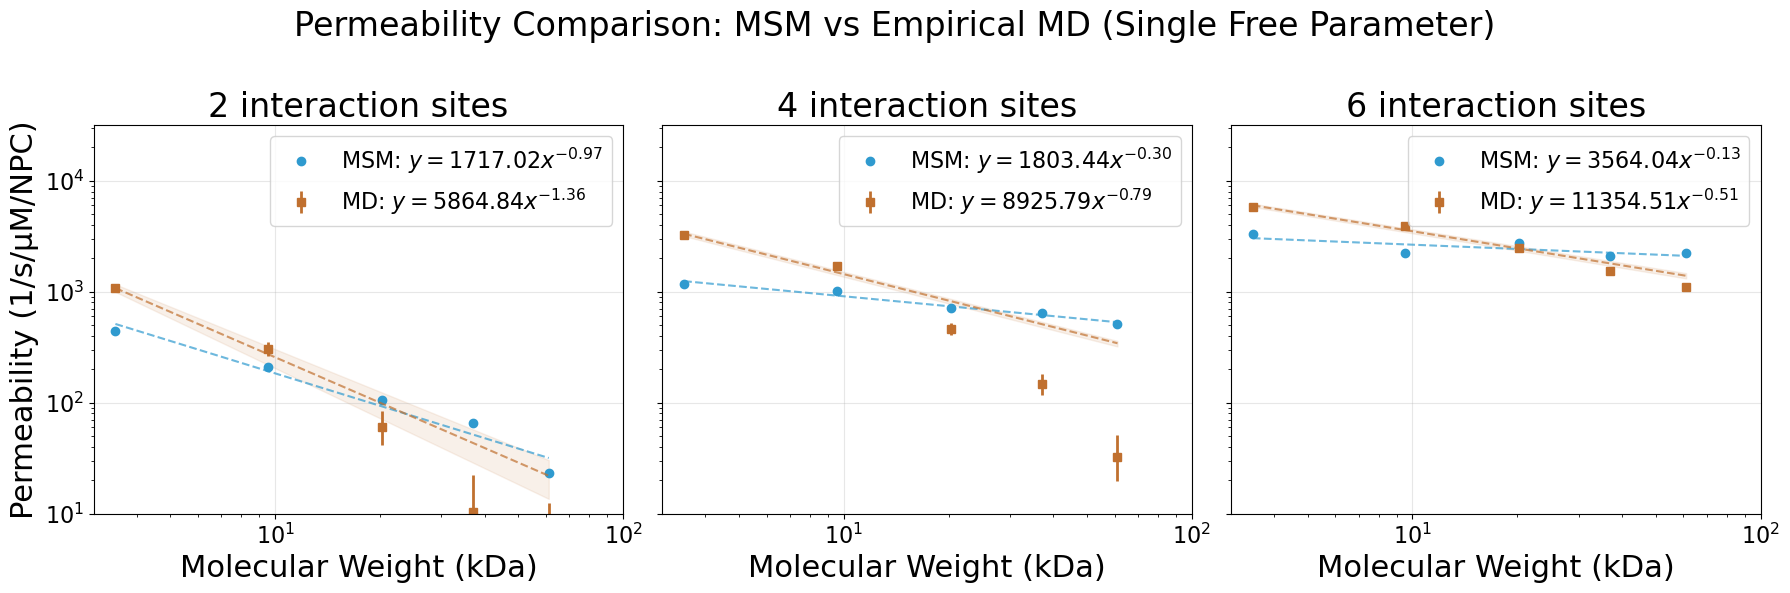


Summary Statistics:
 sites  radius       kda  total_transports  n_trajs  permeability  lower_permeability  upper_permeability
     2      10  3.478309               626     3000   1072.315766          989.948951         1159.707128
     2      14  9.544481               178     3000    304.907678          261.758896          353.138701
     2      18 20.285500                35     3000     59.953757           41.759988           83.381163
     2      22 37.037037                 6     3000     10.277787            3.771767           22.370415
     2      26 61.134764                 2     3000      3.425929            0.414896           12.375633
     4      10  3.478309              1909     3000   3270.049198         3124.988687         3420.105847
     4      14  9.544481               986     3000   1688.982980         1585.191793         1797.785225
     4      18 20.285500               270     3000    462.500410          408.973462          521.086438
     4      22 37.037037 

In [22]:
# print(df_results_emp.to_string(index=False))


def plot_permeability_dataset(ax, data, x_col, y_col, color, label, marker, low_col, high_col):
    if data.empty:
        return

    data = data.sort_values(x_col)

    
    if low_col is not None and high_col is not None:
        y_err_lower = data[y_col] - data[low_col]
        y_err_upper = data[high_col] - data[y_col]
        y_err = (y_err_lower + y_err_upper) / 2
        
        x_fit, y_fit, slope, intercept, _ = weighted_power_law_fit(data[x_col], data[y_col], y_err)
        ax.plot(x_fit, y_fit, linestyle='--', color=color, alpha=0.7)
        
        x_fit_lo, y_fit_lo, _, _, _ = weighted_power_law_fit(data[x_col], data[low_col], y_err)
        x_fit_hi, y_fit_hi, _, _, _ = weighted_power_law_fit(data[x_col], data[high_col], y_err)
        
        ax.fill_between(x_fit, y_fit_lo, y_fit_hi, color=color, alpha=0.1)
        ax.errorbar(
            data[x_col],
            data[y_col],
            yerr=[y_err_lower, y_err_upper],
            marker=marker,
            linestyle='None',
            label=fr'{label}: $y={10**intercept:.2f}x^{{{slope:.2f}}}$',
            color=color,
            linewidth=2,
        )
    else:
        x_fit, y_fit, slope, intercept, _ = weighted_power_law_fit(data[x_col], data[y_col], None)
        ax.plot(x_fit, y_fit, linestyle='--', color=color, alpha=0.7)
        ax.plot(
            data[x_col],
            data[y_col],
            marker=marker,
            linestyle='None',
            label=fr'{label}: $y={10**intercept:.2f}x^{{{slope:.2f}}}$',
            color=color,
            linewidth=2
        )
        

colors = {"MSM": "#2f9acf", "Empirical": "#c0702f"}
site_values = [2, 4, 6]

fig, axes = plt.subplots(1, len(site_values), figsize=(18, 6), sharey=True)
fig.suptitle('Permeability Comparison: MSM vs Empirical MD (Single Free Parameter)', fontsize=24)

for ax, site in zip(axes, site_values):
    msm_site = df_results_tm[df_results_tm['sites'] == site]
    emp_site = df_results_emp[df_results_emp['sites'] == site]
    # if site == 2 and 'total_transports' in emp_site:
    #     emp_site = emp_site[emp_site['total_transports'] > 0]
    free_coeff = 3 # single free parameter
    msm_site.loc[:, 'permeability'] = msm_site['permeability'] / free_coeff
    # emp_site.loc[:, 'lower_permeability'] = emp_site['lower_permeability'] * free_coeff
    # emp_site.loc[:, 'upper_permeability'] = emp_site['upper_permeability'] * free_coeff

    ax.set_title(f'{site} interaction sites', fontsize=24)
    plot_permeability_dataset(
        ax,
        msm_site,
        'kda',
        'permeability',
        colors['MSM'],
        'MSM',
        'o',
        None,
        None
    )
    plot_permeability_dataset(
        ax,
        emp_site,
        'kda',
        'permeability',
        colors['Empirical'],
        'MD',
        's',
        'lower_permeability',
        'upper_permeability'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([10**1, 10**2])
    ax.set_xticklabels([r'$10^1$', r'$10^2$'])
    ax.set_ylim(10, 10**4.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Molecular Weight (kDa)', fontsize=22)
    ax.legend(fontsize=16)
    
    # set tick font size
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

axes[0].set_ylabel('Permeability (1/s/µM/NPC)', fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df_results_emp.to_string(index=False))
print(df_results_tm.to_string(index=False))

In [23]:
# convergence stuff params

radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]
sites_list = [2, 4, 6]
n_clusters = 80
subsets = [0.04, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1]
total_simulation_times = [int(60 * subset) * 30 for subset in subsets]

sims_subsets = [1/30, 2 / 30, 5 / 30, 10 / 30, 15 / 30, 20 / 30, 25 / 30, 1.0]
sims_total_simulation_times = [subset * 30  * 60 for subset in sims_subsets]

In [24]:
# save convergence data
sites_to_fitted_perms = {}
sites_to_fitted_perms_lo = {}
sites_to_fitted_perms_hi = {}

for sites in sites_list:
    sites_perms = []
    sites_perms_lower = []
    sites_perms_upper = []
    sites_errs = []
    for radius in radii:
        kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
        results = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=None)
        perms = results[2]
        perms_lower = results[3]
        perms_upper = results[4]
        y_err_lower = perms - perms_lower
        y_err_upper = perms_upper - perms
        y_err = (y_err_lower + y_err_upper) / 2
        sites_perms.append(perms)
        sites_perms_lower.append(perms_lower)
        sites_perms_upper.append(perms_upper)
        sites_errs.append(y_err)
    sites_perms = np.array(sites_perms)
    sites_perms_lower = np.array(sites_perms_lower)
    sites_perms_upper = np.array(sites_perms_upper)
    sites_errs = np.array(sites_errs)
    _, _, slope, intercept, y_fit = weighted_power_law_fit(kdas, sites_perms, sites_errs)
    _, _, _, _, y_fit_lo = weighted_power_law_fit(kdas, sites_perms_lower, sites_errs)
    _, _, _, _, y_fit_hi = weighted_power_law_fit(kdas, sites_perms_upper, sites_errs)
    sites_to_fitted_perms[sites] = y_fit
    sites_to_fitted_perms_lo[sites] = y_fit_lo
    sites_to_fitted_perms_hi[sites] = y_fit_hi

perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
lower_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
upper_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))

perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))
lower_perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))
upper_perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))

perms_all_msm = np.zeros((len(radii), len(sites_list), len(subsets)))
perms_all_msm_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))



for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):

        # Collect MSM permeabilities (time subset)
        for k, subset in enumerate(subsets):
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction/{0}index/7_permeabilities.pickle", "rb") as f:
                perms = pickle.load(f)
                perms_all_msm[i, j, k] = perms[n_clusters]
                
        # Collect MSM permeabilities (sim subset)
        for k, subset in enumerate(sims_subsets):
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction_simulations/{0}index/7_permeabilities.pickle", "rb") as f:
                perms = pickle.load(f)
                perms_all_msm_sim_subset[i, j, k] = perms[n_clusters]
        
        # Collect MD permeabilities (time subset)
        for k, subset in enumerate(subsets):
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            results = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=int(subset * 60))
            perms_all_md[i, j, k] = results[2]
            lower_perms_all_md[i, j, k] = results[3]
            upper_perms_all_md[i, j, k] = results[4]
            
        # Collect MD permeabilities (sim subset)
        for k, subset in enumerate(sims_subsets):
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            results = collect_perms_md_single_type(kap_coords_folder, n_sims=int(30*subset), start_time=10, end_time=70, shorten_time_to_us=None)
            perms_all_md_sim_subset[i, j, k] = results[2]
            lower_perms_all_md_sim_subset[i, j, k] = results[3]
            upper_perms_all_md_sim_subset[i, j, k] = results[4]
    
# save convergence data
# md time subset
with open("data/convergence/perms_all_md.pickle", "wb") as f:
    pickle.dump(perms_all_md, f)
with open("data/convergence/lower_perms_all_md.pickle", "wb") as f:
    pickle.dump(lower_perms_all_md, f)
with open("data/convergence/upper_perms_all_md.pickle", "wb") as f:
    pickle.dump(upper_perms_all_md, f)
    
# md sim subset
with open("data/convergence/perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(perms_all_md_sim_subset, f)
with open("data/convergence/lower_perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(lower_perms_all_md_sim_subset, f)
with open("data/convergence/upper_perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(upper_perms_all_md_sim_subset, f)

# msm time subset
with open("data/convergence/perms_all_msm.pickle", "wb") as f:
    pickle.dump(perms_all_msm, f)

# msm sim subset
with open("data/convergence/perms_all_msm_sim_subset.pickle", "wb") as f:
    pickle.dump(perms_all_msm_sim_subset, f)

# ideal fits
with open("data/convergence/sites_to_fitted_perms.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms, f)
with open("data/convergence/sites_to_fitted_perms_lo.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms_lo, f)
with open("data/convergence/sites_to_fitted_perms_hi.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms_hi, f)

In [25]:
# load convergence data
# md time subset
with open("data/convergence/perms_all_md.pickle", "rb") as f:
    perms_all_md = pickle.load(f)
with open("data/convergence/lower_perms_all_md.pickle", "rb") as f:
    lower_perms_all_md = pickle.load(f)
with open("data/convergence/upper_perms_all_md.pickle", "rb") as f:
    upper_perms_all_md = pickle.load(f)
    
# md sim subset
with open("data/convergence/perms_all_md_sim_subset.pickle", "rb") as f:
    perms_all_md_sim_subset = pickle.load(f)
with open("data/convergence/lower_perms_all_md_sim_subset.pickle", "rb") as f:
    lower_perms_all_md_sim_subset = pickle.load(f)
with open("data/convergence/upper_perms_all_md_sim_subset.pickle", "rb") as f:
    upper_perms_all_md_sim_subset = pickle.load(f)
    
# msm time subset
with open("data/convergence/perms_all_msm.pickle", "rb") as f:
    perms_all_msm = pickle.load(f)
    
# msm sim subset
with open("data/convergence/perms_all_msm_sim_subset.pickle", "rb") as f:
    perms_all_msm_sim_subset = pickle.load(f)

# ideal fits
with open("data/convergence/sites_to_fitted_perms.pickle", "rb") as f:
    sites_to_fitted_perms = pickle.load(f)
with open("data/convergence/sites_to_fitted_perms_lo.pickle", "rb") as f:
    sites_to_fitted_perms_lo = pickle.load(f)
with open("data/convergence/sites_to_fitted_perms_hi.pickle", "rb") as f:
    sites_to_fitted_perms_hi = pickle.load(f)
    
print(perms_all_msm_sim_subset[:, :, -2])

[[ 1030.4509143   2797.51081551  9652.69189799]
 [  754.80066972  2793.19414502 10590.33439661]
 [  555.00049244  2067.99350156  8800.14947488]
 [  141.21679197  1878.98500052  8906.21623565]
 [  240.808547    1366.53454583  7021.06456299]]


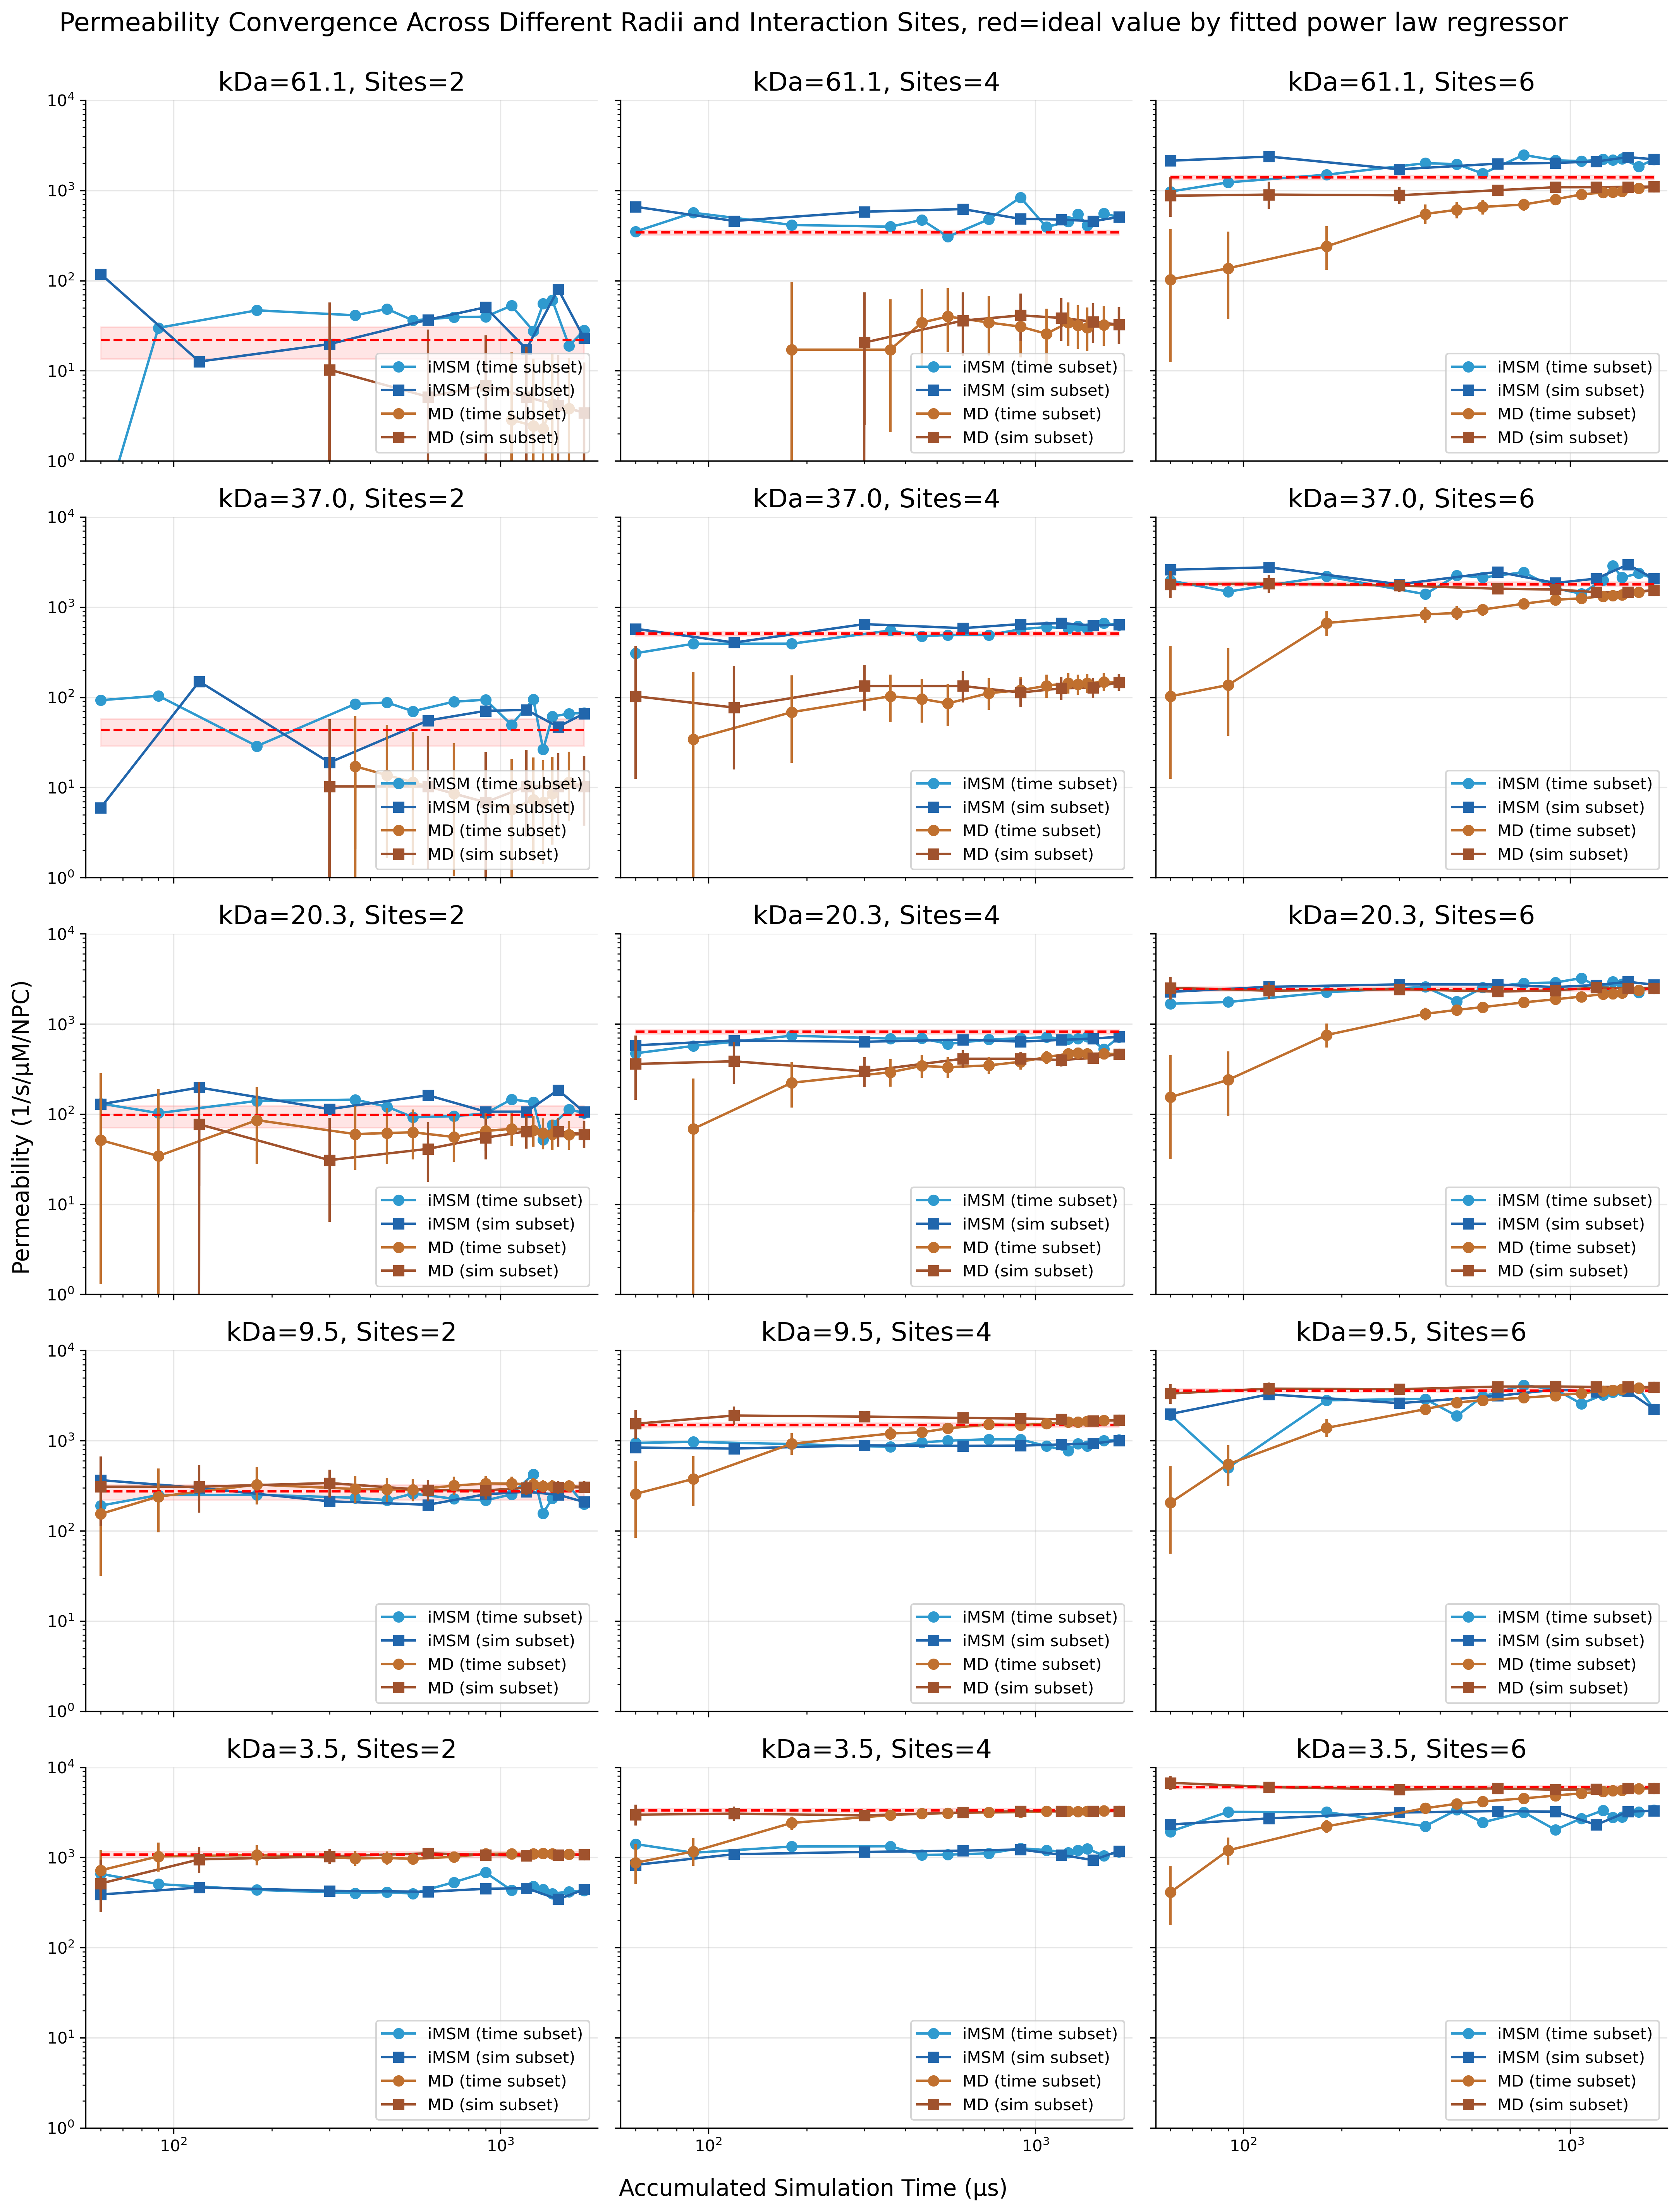

In [27]:

fig, axes = plt.subplots(len(radii), len(sites_list), figsize=(15, 20), sharex=True, sharey=True, dpi=300)

for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        ax = axes[len(radii) - i - 1, j]
        md_perms = perms_all_md[i, j, :]
        md_lower_perms = lower_perms_all_md[i, j, :]
        md_upper_perms = upper_perms_all_md[i, j, :]
        
        md_perms_sim_subset = perms_all_md_sim_subset[i, j, :]
        md_lower_perms_sim_subset = lower_perms_all_md_sim_subset[i, j, :]
        md_upper_perms_sim_subset = upper_perms_all_md_sim_subset[i, j, :]
        
        msm_perms = perms_all_msm[i, j, :]
        msm_sim_subset_perms = perms_all_msm_sim_subset[i, j, :]
        div_factor = 3  # single free parameter
        
        # Plot
        ax.plot(total_simulation_times, msm_perms / div_factor, marker='o', label='iMSM (time subset)', color="#2f9acf")
        ax.plot(sims_total_simulation_times, msm_sim_subset_perms / div_factor, marker='s', label='iMSM (sim subset)', color="#2166ac")
        ax.plot(total_simulation_times, md_perms, marker='o', label='MD (time subset)', color="#c0702f")
        ax.plot(sims_total_simulation_times, md_perms_sim_subset, marker='s', label='MD (sim subset)', color="#a0522d")
        ax.errorbar(
            total_simulation_times,
            md_perms,
            yerr=[np.array(md_perms) - np.array(md_lower_perms), np.array(md_upper_perms) - np.array(md_perms)],
            fmt='o',
            color="#c0702f"
        )
        ax.errorbar(
            sims_total_simulation_times,
            md_perms_sim_subset,
            yerr=[np.array(md_perms_sim_subset) - np.array(md_lower_perms_sim_subset), np.array(md_upper_perms_sim_subset) - np.array(md_perms_sim_subset)],
            fmt='s',
            color="#a0522d"
        )
        
        # Add title for each subplot
        ax.set_title(f'kDa={kdas[i]:.1f}, Sites={sites}', fontsize=16)
        
        ax.legend(loc='lower right')
        
        # Grid
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # add red dashed line for the final md value
        ax.plot(total_simulation_times, [sites_to_fitted_perms[sites][i]] * len(total_simulation_times), color='red', linestyle='--')
        ax.fill_between(total_simulation_times, sites_to_fitted_perms_lo[sites][i], sites_to_fitted_perms_hi[sites][i], color='red', alpha=0.1)
        
        ax.set_xlim(total_simulation_times[0]*0.9, total_simulation_times[-1]*1.1)
        ax.set_ylim(10**0, 10**4)
        
        # hide spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Add common axis labels
fig.text(0.5, 0.04, 'Accumulated Simulation Time (μs)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Permeability (1/s/µM/NPC)', va='center', rotation='vertical', fontsize=14)

fig.suptitle('Permeability Convergence Across Different Radii and Interaction Sites, red=ideal value by fitted power law regressor', fontsize=16)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
plt.show()

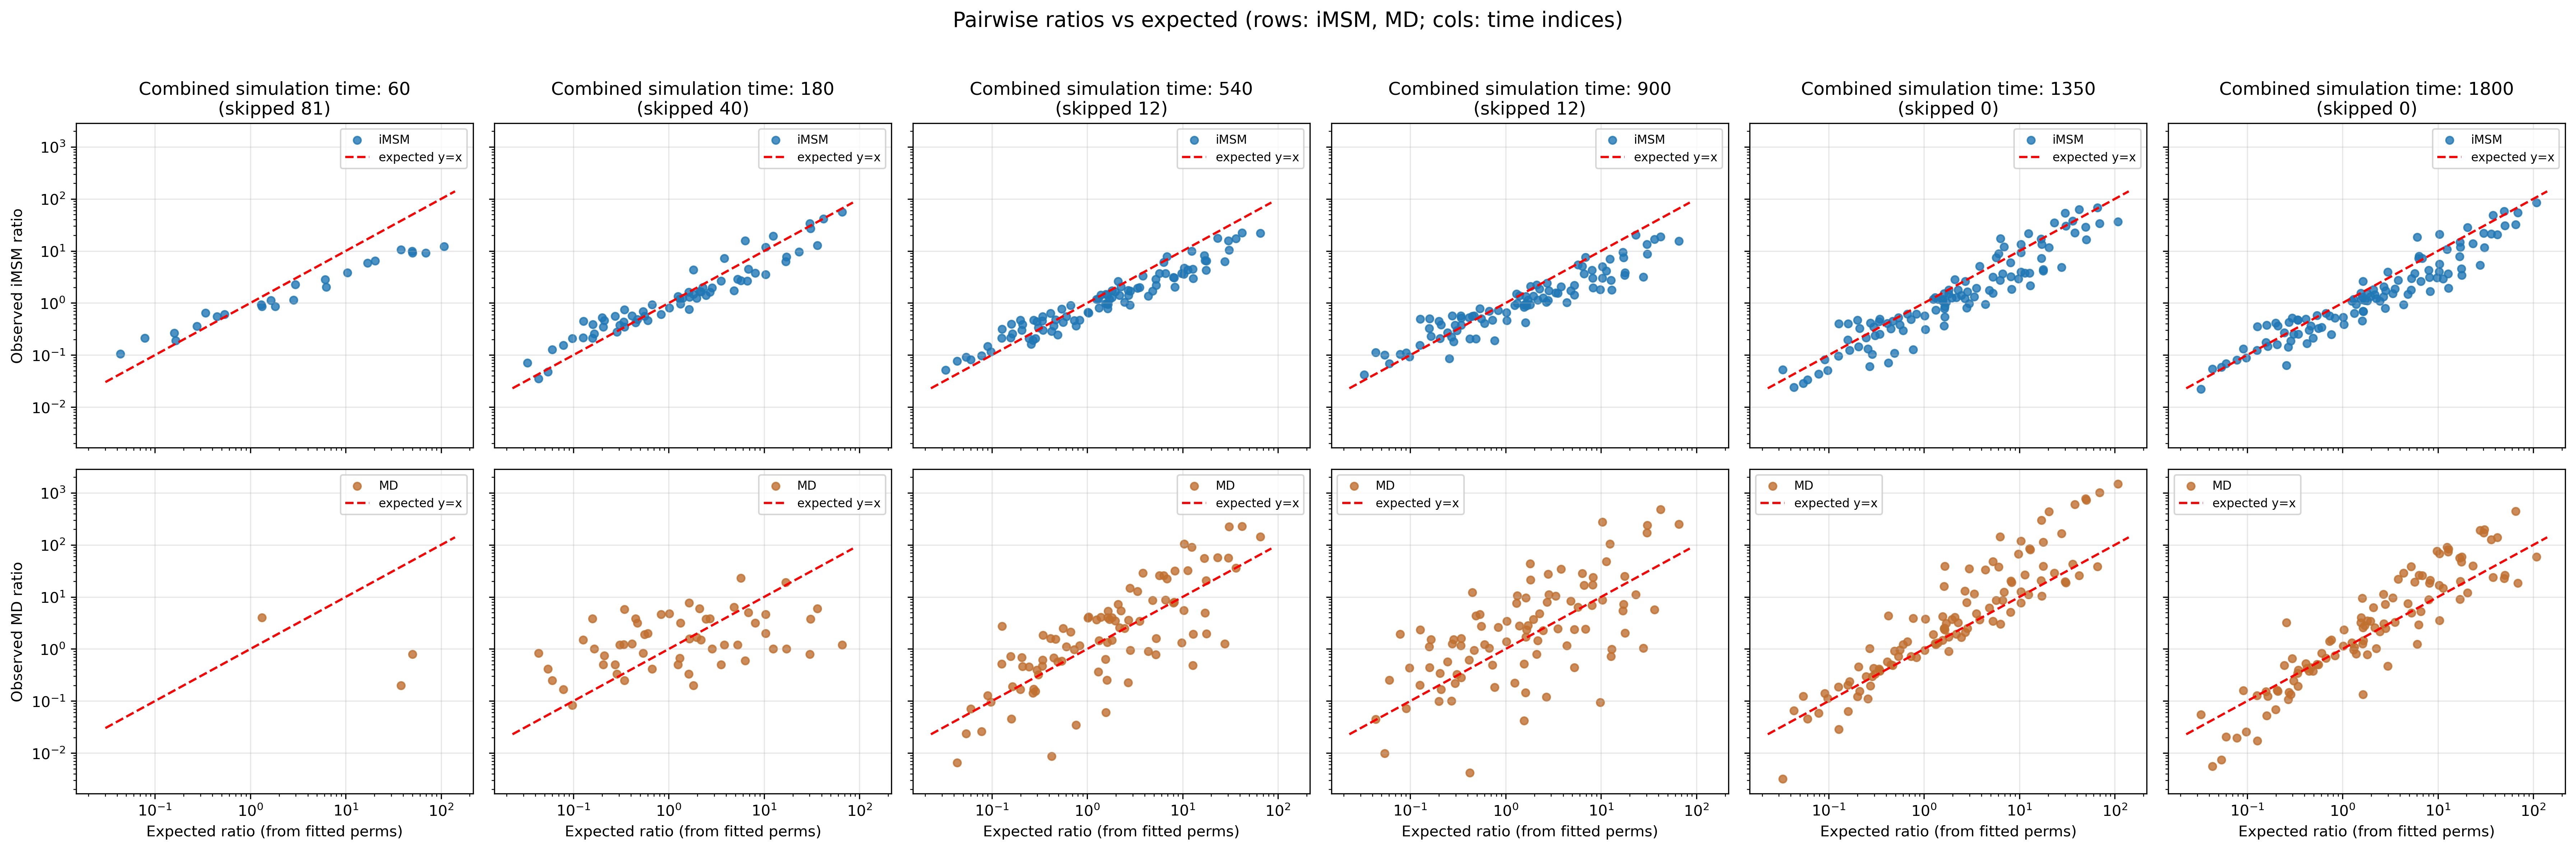

In [9]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# pick up to 5 evenly spaced time indices across the trajectory
max_cols = 6
time_indices = np.linspace(
    0, perms_all_msm.shape[2] - 1,
    num=min(max_cols, perms_all_msm.shape[2]),
    dtype=int
)

combos = [(i, j) for i in range(len(radii)) for j in range(len(sites_list))]

def expected_ratio(i1, j1, i2, j2):
    num = sites_to_fitted_perms[sites_list[j1]][i1]
    den = sites_to_fitted_perms[sites_list[j2]][i2]
    if den == 0:
        return None
    return num / den

fig, axes = plt.subplots(2, len(time_indices), figsize=(4*len(time_indices), 8), dpi=300, sharex=True, sharey=True)

for col, t_idx in enumerate(time_indices):
    # collect ratios
    exp_vals = []
    msm_vals = []
    md_vals = []
    skipped = 0

    for (i1, j1), (i2, j2) in itertools.combinations(combos, 2):
        exp_r = expected_ratio(i1, j1, i2, j2)
        if exp_r is None or exp_r == 0:
            skipped += 1
            continue

        # observed ratios; skip if denominator is zero
        msm_den = perms_all_msm[i2, j2, t_idx]
        md_den = perms_all_md[i2, j2, t_idx]
        if msm_den == 0 or md_den == 0:
            skipped += 1
            continue

        msm_r = perms_all_msm[i1, j1, t_idx] / msm_den
        md_r = perms_all_md[i1, j1, t_idx] / md_den

        exp_vals.append(exp_r)
        msm_vals.append(msm_r)
        md_vals.append(md_r)

    exp_vals = np.array(exp_vals)
    msm_vals = np.array(msm_vals)
    md_vals = np.array(md_vals)

    # row 0: iMSM vs expected
    ax0 = axes[0, col] if axes.ndim == 2 else axes[col]
    ax0.scatter(exp_vals, msm_vals, alpha=0.8, s=25, label='iMSM')
    xline = np.logspace(np.log10(exp_vals.min()*0.7), np.log10(exp_vals.max()*1.3), 200)
    ax0.plot(xline, xline, color='red', ls='--', lw=1.5, label='expected y=x')
    ax0.set_xscale('log')
    ax0.set_yscale('log')
    ax0.set_title(f"Combined simulation time: {total_simulation_times[t_idx]}\n(skipped {skipped})")
    ax0.grid(True, alpha=0.3)
    if col == 0:
        ax0.set_ylabel("Observed iMSM ratio")
    ax0.legend(fontsize=8)

    # row 1: MD vs expected
    ax1 = axes[1, col] if axes.ndim == 2 else axes[col]
    ax1.scatter(exp_vals, md_vals, alpha=0.8, s=25, color="#c0702f", label='MD')
    ax1.plot(xline, xline, color='red', ls='--', lw=1.5, label='expected y=x')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    if col == 0:
        ax1.set_ylabel("Observed MD ratio")
    ax1.set_xlabel("Expected ratio (from fitted perms)")
    ax1.legend(fontsize=8)

plt.suptitle("Pairwise ratios vs expected (rows: iMSM, MD; cols: time indices)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

[[  90.  360.  720.]
 [  90.  540.  720.]
 [  60.  720.  900.]
 [ 540.  720.  900.]
 [1080.  450. 1080.]] [[ 90.  60.  90.]
 [ 60.  60.  60.]
 [ 60.  90. 180.]
 [360. 360.  60.]
 [ 90.  90. 360.]]


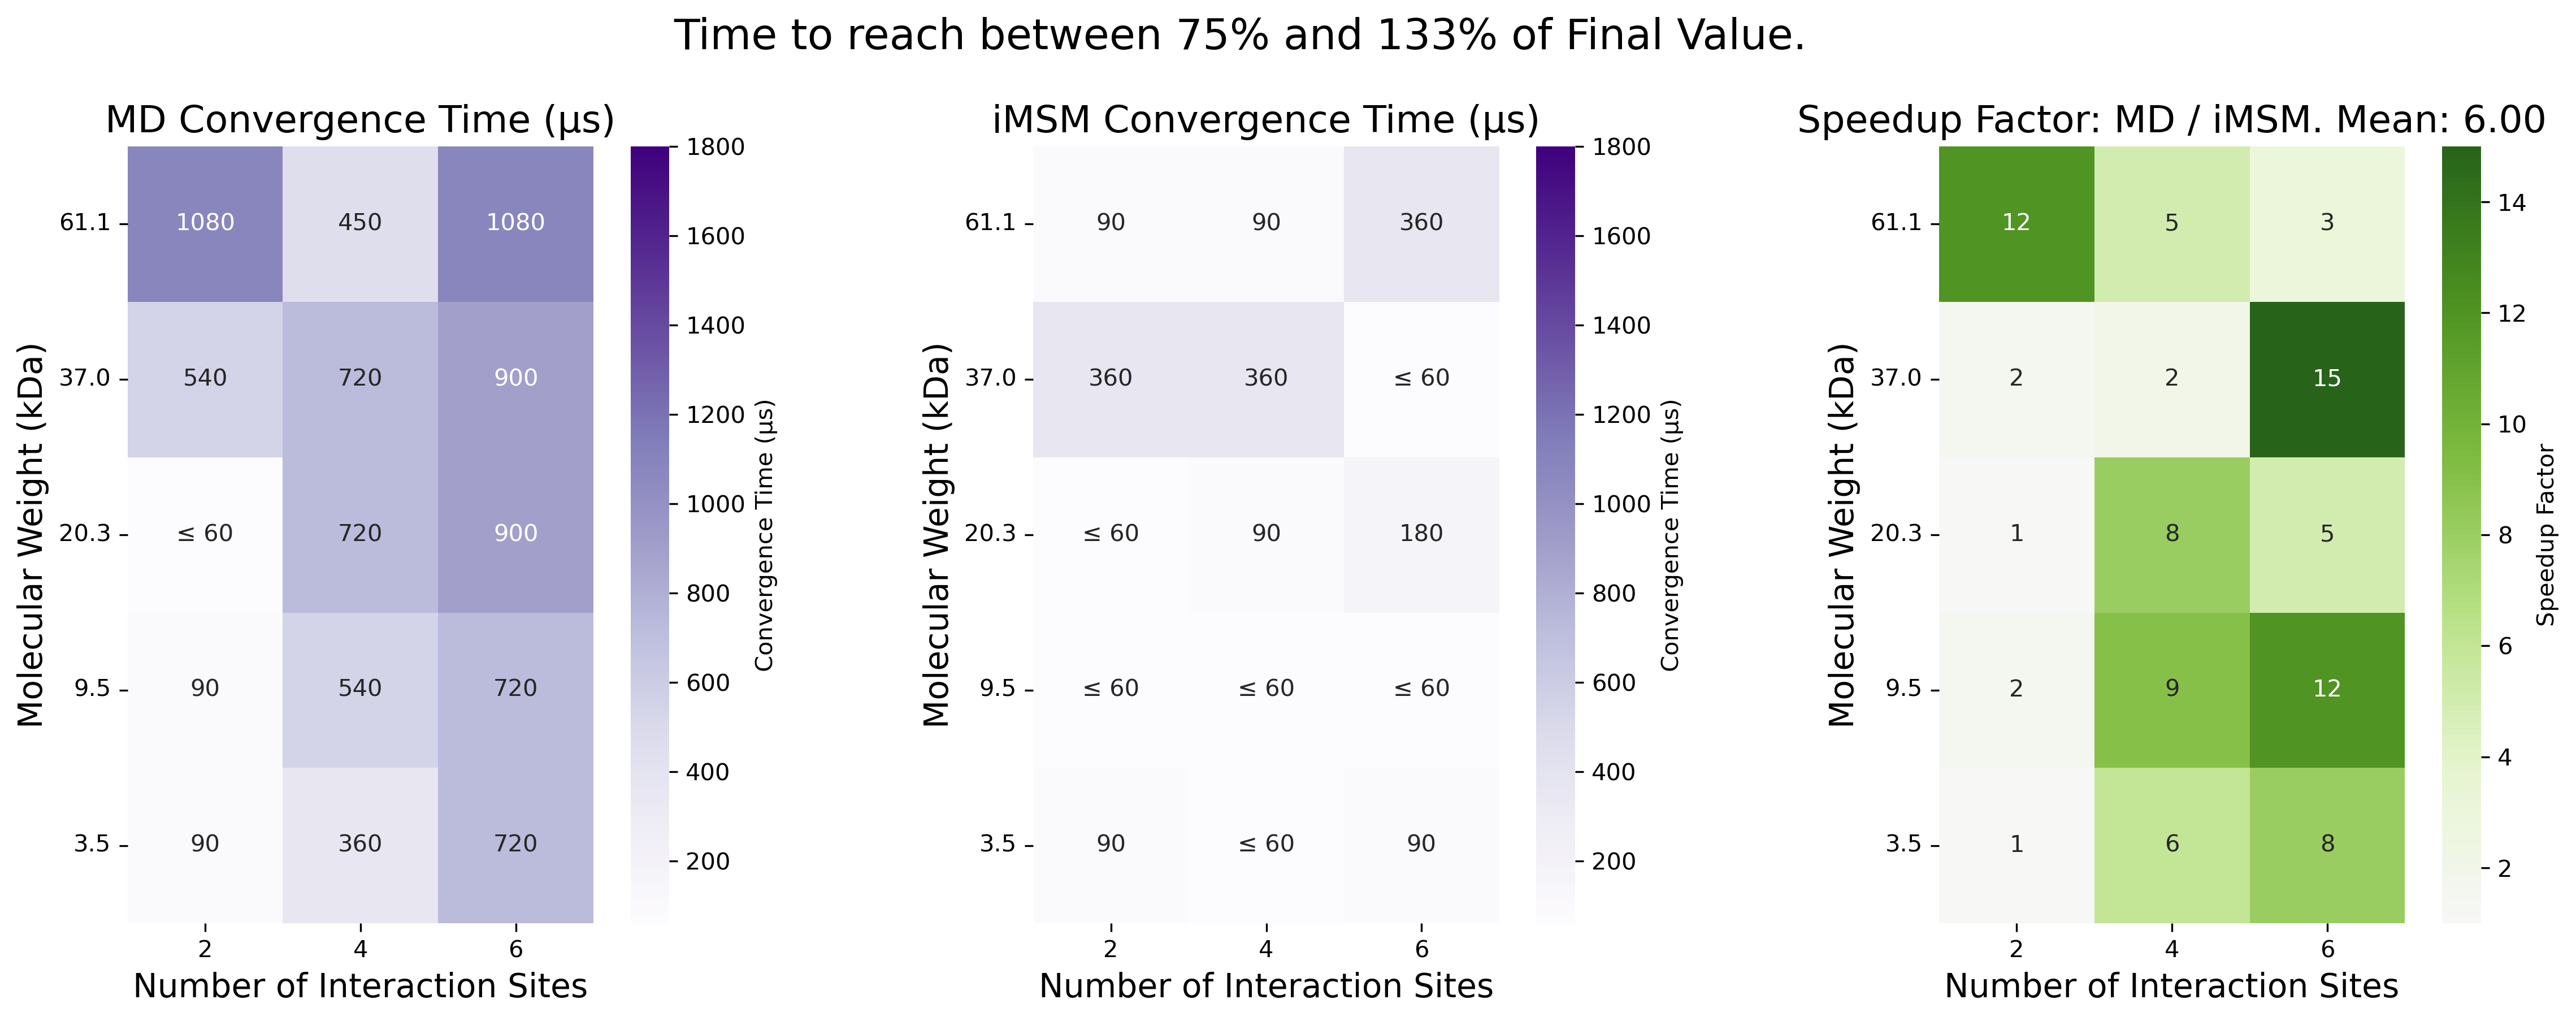

In [30]:
min_convergence_factor = 0.75
max_convergence_factor = 1.33

# min_convergence_factor = 0.5
# max_convergence_factor = 1.5


md_convergences = np.zeros((len(radii), len(sites_list)))
msm_convergences = np.zeros((len(radii), len(sites_list)))
for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        md_perms = perms_all_md[i, j, :]
        msm_perms = perms_all_msm[i, j, :]
        final_md_perm = md_perms[-1]
        final_msm_perm = msm_perms[-1]
        for k in range(len(subsets)):
            if md_perms[k] >= min_convergence_factor * final_md_perm and md_perms[k] <= max_convergence_factor * final_md_perm:
                md_convergences[i, j] = total_simulation_times[k]
                break
        for k in range(len(subsets)):
            if msm_perms[k] >= min_convergence_factor * final_msm_perm and msm_perms[k] <= max_convergence_factor * final_msm_perm:
                msm_convergences[i, j] = total_simulation_times[k]
                break

min_convergence_time = 60
max_convergence_time = 1800
def format_val(v):
    if np.isnan(v) or v == 0:  # adjust if 0 means "no data"
        return ""
    if v >= max_convergence_time:
        return f"\u2265 {max_convergence_time}"
    if v <= min_convergence_time:
        return f"\u2264 {min_convergence_time}"
    return f"{v:.0f}"

md_labels = np.vectorize(format_val)(md_convergences[::-1])
msm_labels = np.vectorize(format_val)(msm_convergences[::-1])

# visualize as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=300)
fig.suptitle('Time to reach between 75% and 133% of Final Value. ', 
             fontsize=18, y=0.995)

# MD heatmap
sns.heatmap(md_convergences[::-1], annot=md_labels, fmt='', cmap='Purples', 
            ax=axes[0], cbar_kws={'label': 'Convergence Time (μs)'}, square=True,
            vmin=min_convergence_time, vmax=max_convergence_time)
axes[0].set_xticklabels(sites_list)
axes[0].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[0].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[0].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[0].set_title('MD Convergence Time (μs)', fontsize=16)


# MSM heatmap
sns.heatmap(msm_convergences[::-1], annot=msm_labels, fmt='', cmap='Purples', 
            ax=axes[1], cbar_kws={'label': 'Convergence Time (μs)'}, square=True,
            vmin=min_convergence_time, vmax=max_convergence_time)
axes[1].set_xticklabels(sites_list)
axes[1].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[1].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[1].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[1].set_title('iMSM Convergence Time (μs)', fontsize=16)


# Speedup factor heatmap (MD / MSM)
speedup_factor = md_convergences / msm_convergences
print(md_convergences, msm_convergences)
sns.heatmap(speedup_factor[::-1], annot=True, fmt='.0f', cmap='PiYG', center=1,
            ax=axes[2], cbar_kws={'label': 'Speedup Factor'}, square=True)
axes[2].set_xticklabels(sites_list)
axes[2].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
axes[2].set_xlabel('Number of Interaction Sites', fontsize=14)
axes[2].set_ylabel('Molecular Weight (kDa)', fontsize=14)
axes[2].set_title(f'Speedup Factor: MD / iMSM. Mean: {np.mean(speedup_factor):.2f}', fontsize=16)

# # Difference heatmap (MD - MSM)
# diff_convergences = md_convergences - msm_convergences
# sns.heatmap(diff_convergences[::-1], annot=True, fmt='.0f', cmap='RdBu_r', center=0,
#             ax=axes[1, 0], cbar_kws={'label': 'Difference (μs)'}, square=True)
# axes[1, 0].set_xticklabels(sites_list)
# axes[1, 0].set_yticklabels([f"{kda:.1f}" for kda in kdas[::-1]], rotation=0)
# axes[1, 0].set_xlabel('Number of Interaction Sites', fontsize=14)
# axes[1, 0].set_ylabel('Molecular Weight (kDa)', fontsize=14)
# axes[1, 0].set_title('Difference: MD - iMSM (μs)', fontsize=16)



plt.tight_layout()

time subset total time = 60, sim subset total time = 60.0
time subset total time = 180, sim subset total time = 120.0
time subset total time = 450, sim subset total time = 600.0
time subset total time = 900, sim subset total time = 900.0
time subset total time = 1800, sim subset total time = 1800.0


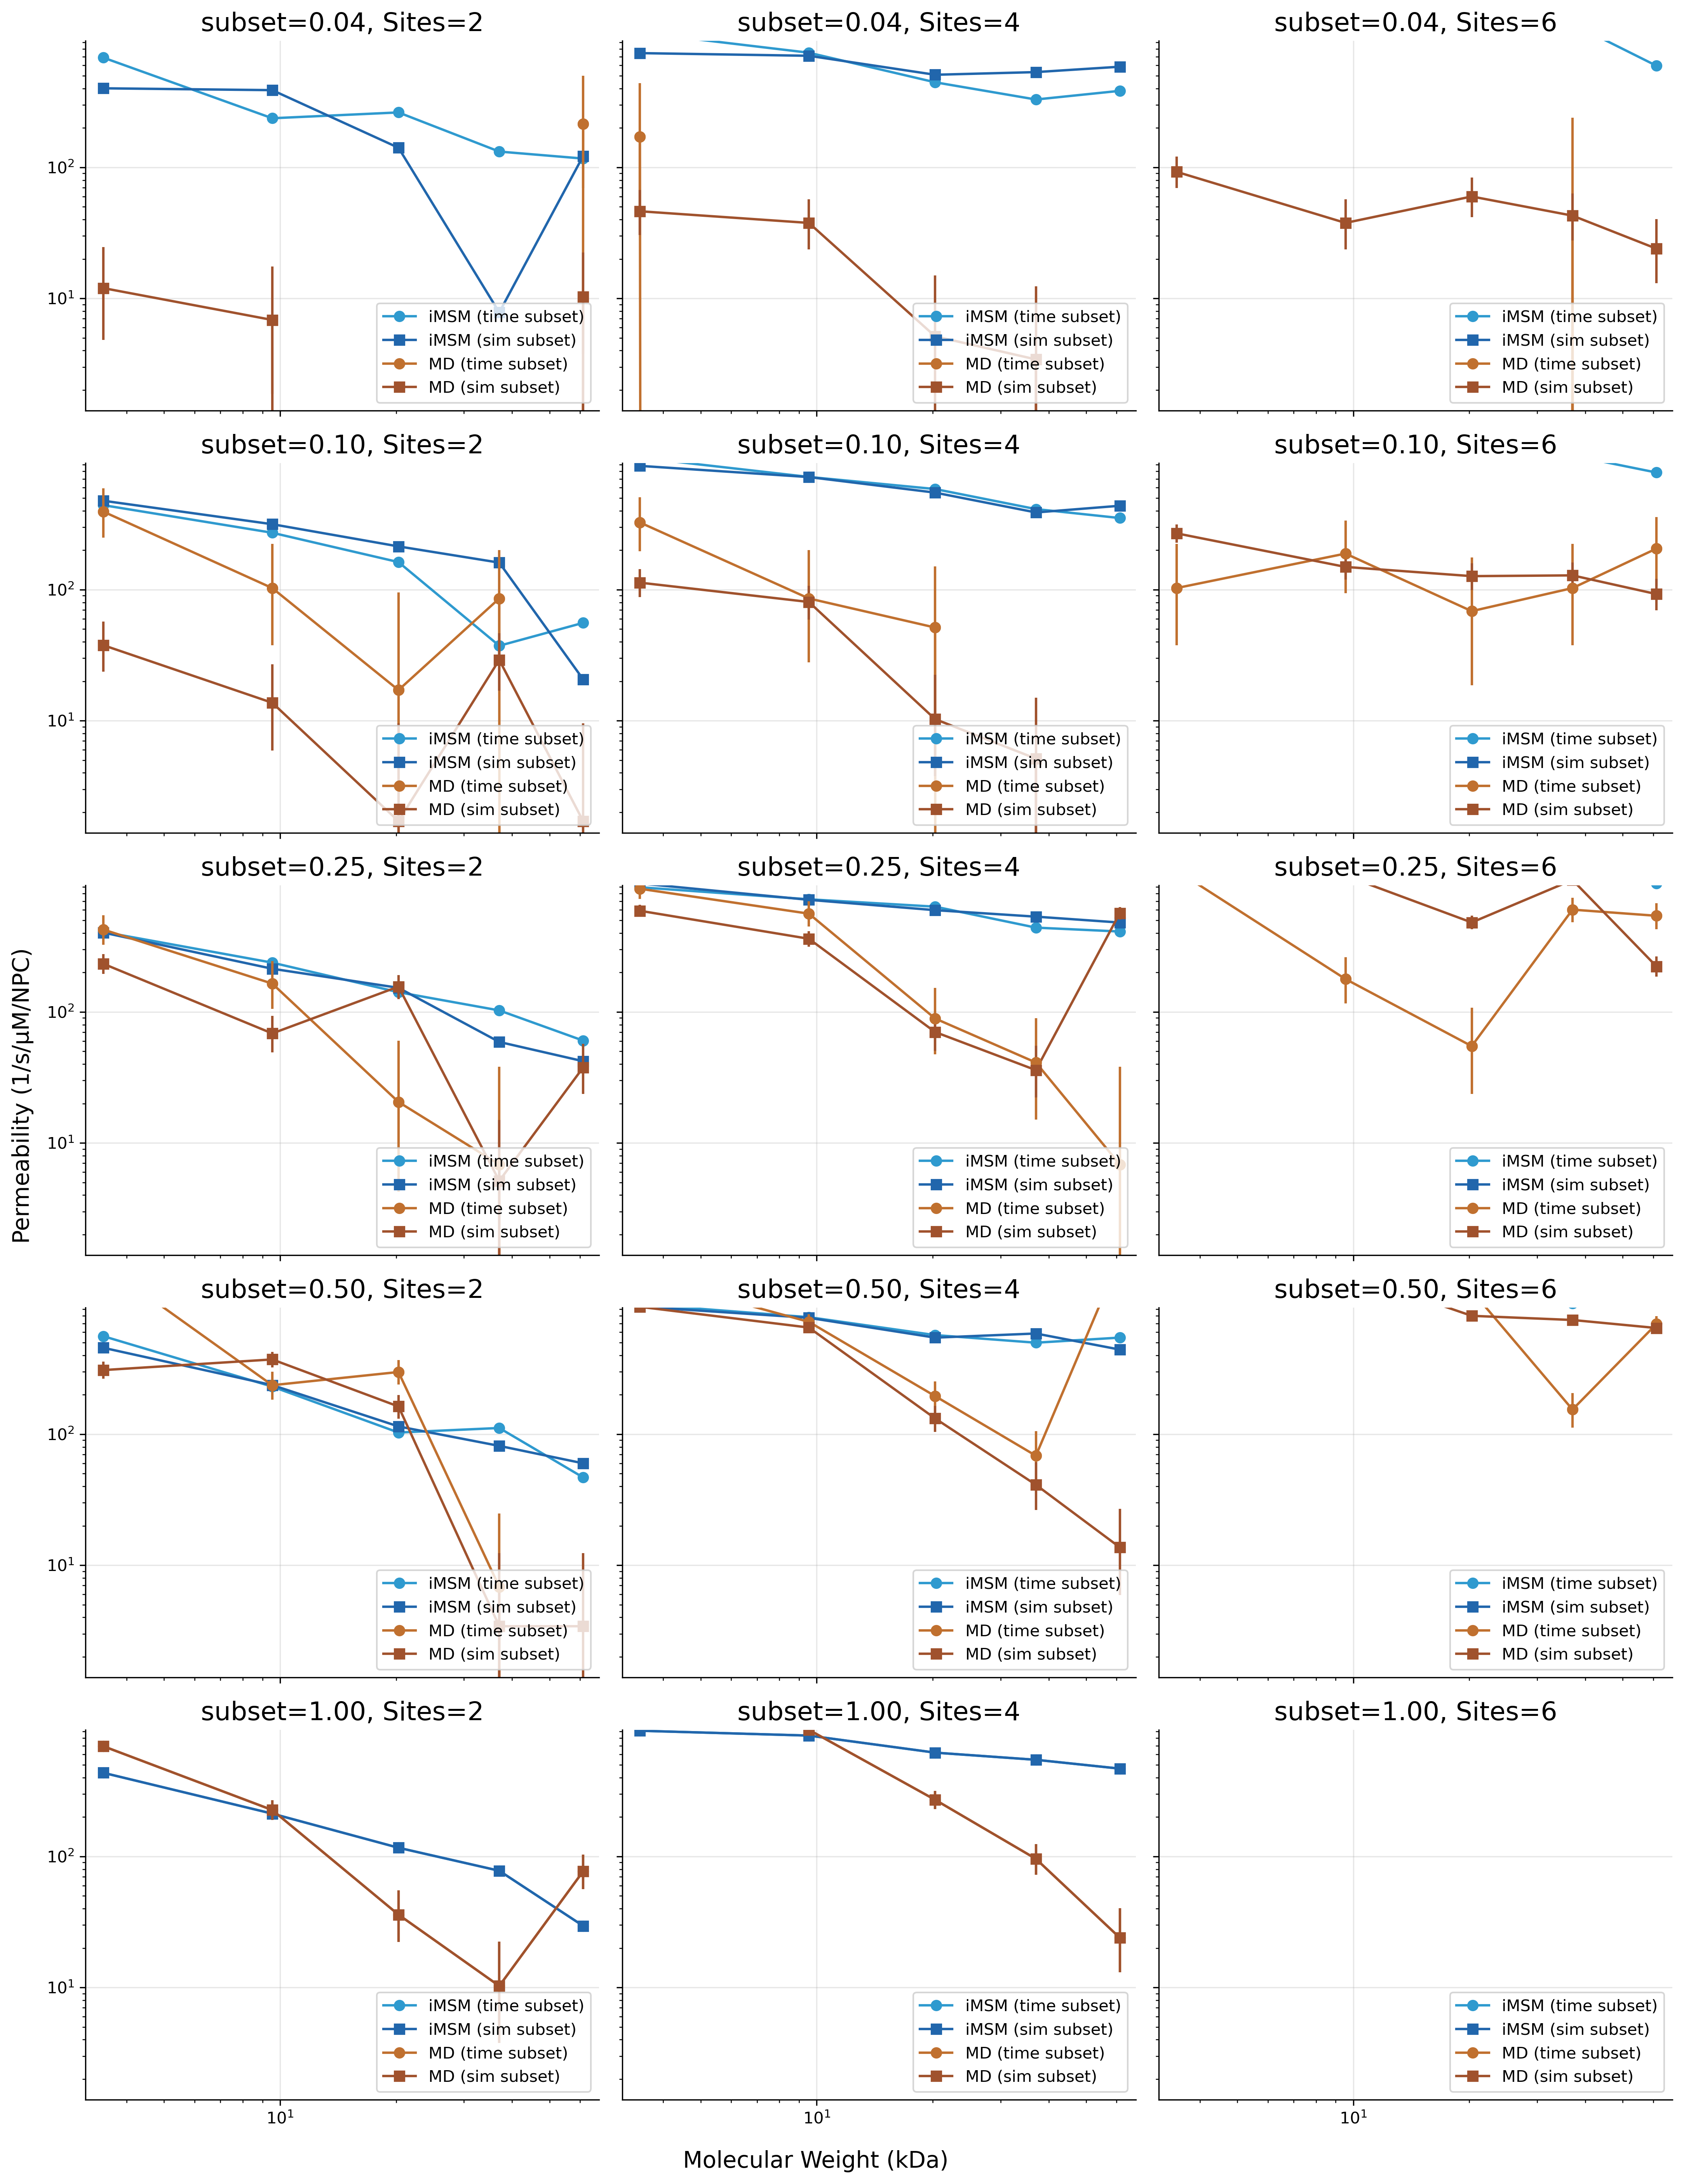

In [16]:

fig, axes = plt.subplots(5, len(sites_list), figsize=(15, 20), sharex=True, sharey=True, dpi=300)

indexes_for_time_sites_fig = []
indexes_sim_for_time_sites_fig = []
subset_sizes_for_time_sites_fig = [0.04, 0.1, 0.25, 0.5, 1.0]
# find the subset indices of 0.04, 0.1, 0.25, 0.5, 1.0
for target in subset_sizes_for_time_sites_fig:\
    # not exact
    idx = np.argmin(np.abs(np.array(subsets) - target))
    indexes_for_time_sites_fig.append(idx)
    idx = np.argmin(np.abs(np.array(sims_subsets) - target))
    indexes_sim_for_time_sites_fig.append(idx)


for plt_idx, (i_time_sub, i_sim_sub) in enumerate(zip(indexes_for_time_sites_fig, indexes_sim_for_time_sites_fig)):
    print(f"time subset total time = {total_simulation_times[i_time_sub]}, sim subset total time = {sims_total_simulation_times[i_sim_sub]}")
    
    for j, sites in enumerate(sites_list):
        ax = axes[plt_idx, j]
        md_perms = perms_all_md[:, j, i_time_sub]
        md_lower_perms = lower_perms_all_md[:, j, i_time_sub]
        md_upper_perms = upper_perms_all_md[:, j, i_time_sub]
        
        md_perms_sim_subset = perms_all_md_sim_subset[:, j, i_sim_sub]
        md_lower_perms_sim_subset = lower_perms_all_md_sim_subset[:, j, i_sim_sub]
        md_upper_perms_sim_subset = upper_perms_all_md_sim_subset[:, j, i_sim_sub]
        
        msm_perms = perms_all_msm[:, j, i_time_sub]
        msm_sim_subset_perms = perms_all_msm_sim_subset[:, j, i_sim_sub]
        div_factor = 5  # single free parameter
        
        # Plot
        ax.plot(kdas, msm_perms / div_factor, marker='o', label='iMSM (time subset)', color="#2f9acf")
        ax.plot(kdas, msm_sim_subset_perms / div_factor, marker='s', label='iMSM (sim subset)', color="#2166ac")
        ax.plot(kdas, md_perms, marker='o', label='MD (time subset)', color="#c0702f")
        ax.plot(kdas, md_perms_sim_subset, marker='s', label='MD (sim subset)', color="#a0522d")
        ax.errorbar(
            kdas,
            md_perms,
            yerr=[np.array(md_perms) - np.array(md_lower_perms), np.array(md_upper_perms) - np.array(md_perms)],
            fmt='o',
            color="#c0702f"
        )
        ax.errorbar(
            kdas,
            md_perms_sim_subset,
            yerr=[np.array(md_perms_sim_subset) - np.array(md_lower_perms_sim_subset), np.array(md_upper_perms_sim_subset) - np.array(md_perms_sim_subset)],
            fmt='s',
            color="#a0522d"
        )
        
        # Add title for each subplot
        ax.set_title(f'subset={subset_sizes_for_time_sites_fig[plt_idx]:.2f}, Sites={sites}', fontsize=16)
        
        ax.legend(loc='lower right')
        
        # Grid
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # add red dashed line for the final md value
        # ax.plot(kdas, [sites_to_fitted_perms[sites][i]] * len(kdas), color='red', linestyle='--')
        # ax.fill_between(kdas, sites_to_fitted_perms_lo[sites][i], sites_to_fitted_perms_hi[sites][i], color='red', alpha=0.1)
        
        ax.set_xlim(kdas[0]*0.9, kdas[-1]*1.1)
        ax.set_ylim()
        
        # hide spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Add common axis labels
fig.text(0.5, 0.04, 'Molecular Weight (kDa)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Permeability (1/s/µM/NPC)', va='center', rotation='vertical', fontsize=14)

fig.suptitle('', fontsize=16)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
plt.show()